# Cálculo de distancias en Cosmología

En este código se calcularán distancias cosmológicas y evoluciones de densidad. Para ello se necesita tener presentes las siguientes ecuaciones matemáticas:

## Función de Hubble

$H(z) = H_0\sqrt{\Omega_{M,0}(1+z)^3 + \Omega_{R,0} (1+z)^4 + \Omega_{\Lambda}}$


## Distancia comóvil

$\chi (z_{emit}) = \frac{c}{H_0} \int_{0}^{z_{emit}} \frac{dz}{\sqrt{\Omega_{M,0}(1+z)^3 + \Omega_{R,0} (1+z)^4 + \Omega_{\Lambda}}}$

## Distancia angular

$D_A (z_{emit}) = \frac{\chi (z_{emit})}{(1+z_{emit})}=\frac{c}{(1+z_{emit})H_0} \int_{0}^{z_{emit}} \frac{dz}{\sqrt{\Omega_{M,0}(1+z)^3 + \Omega_{R,0} (1+z)^4 + \Omega_{\Lambda}}}$

## Distancia luminosa
$D_l (z_{emit}) = (1+z_{emit}) \times \chi (z_{emit})=\frac{c (1+z_{emit})}{H_0} \int_{0}^{z_{emit}} \frac{dz}{\sqrt{\Omega_{M,0}(1+z)^3 + \Omega_{R,0} (1+z)^4 + \Omega_{\Lambda}}}$


In [1]:
#Importamos las librerías que nos serán de utilidad
import numpy as np
import math as mth
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",        # 'cm', 'stix', 'stixsans', 'dejavusans'
    "font.serif": ["STIXGeneral", "Times New Roman"],
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "figure.figsize": (6, 4)
})

In [3]:
#En esta celda colocaremos las funciones principales a utilizar

#Función que nos ayudará a calcular la interal sobre el redshift

def simpson(f, a, b, N):
    """
    Calcula la integral definida de una función usando el método de Simpson.

    Args:
      f: La función a integrar.
      a: Límite inferior de integración.
      b: Límite superior de integración.
      N: Número de subintervalos.

    Returns:
      El valor de la integral.
    """
    s1 = 0
    s2 = 0
    h = (b - a) / N
    
    for i in range(2, N - 1, 2):
        s1 += f(a + i * h)
    
    for j in range(1, N, 2):
        s2 += f(a + j * h)
    
    I = (h / 3) * (f(a) + f(b) + 2 * s1 + 4 * s2)
    return I

#prueba
#f = lambda x: np.cos(x+1)
#I1 = simpson(f,0,2*mth.pi,10000)
#print(I1)

def Hubble(z,H0,omega_m,omega_R,omega_l):
    H = H0*np.sqrt(omega_m*(1+z)**3 + omega_R*(1+z)**4 + omega_l)
    return H
    
def d_comovil(z_emit,H0,omega_m,omega_R,omega_l,n=10000):
    h = lambda z: 1/Hubble(z,H0,omega_m,omega_R,omega_l)
    I = simpson(h,0,z_emit,n)
    D_comovil = (c*(1+z_emit))*I
    return D_comovil

def d_lumin(z_emit,H0,omega_m,omega_R,omega_l,n=10000):
    # acá D_comovil ya es un número resultado de la evaluación de la función d_comovil
    D_lumin = (1 + z_emit)*d_comovil(z_emit,H0,omega_m,omega_R,omega_l,n=10000)
    return D_lumin

def d_angular(z_emit,H0,omega_m,omega_R,omega_l,n=10000):
    D_angular = d_comovil(z_emit,H0,omega_m,omega_R,omega_l,n=10000)/(1 + z_emit)
    return D_angular

In [4]:
#Ahora definimos los parámetros que serán importantes para nuestros cálculos
#H_o70 km/s/Mpc
H0 = 70*1000 #expresa las unidades a h km(s^-1 Gpc^-1)
c = 299792 #km/s
omega_m = 0.3
omega_l = 0.7
omega_R=0

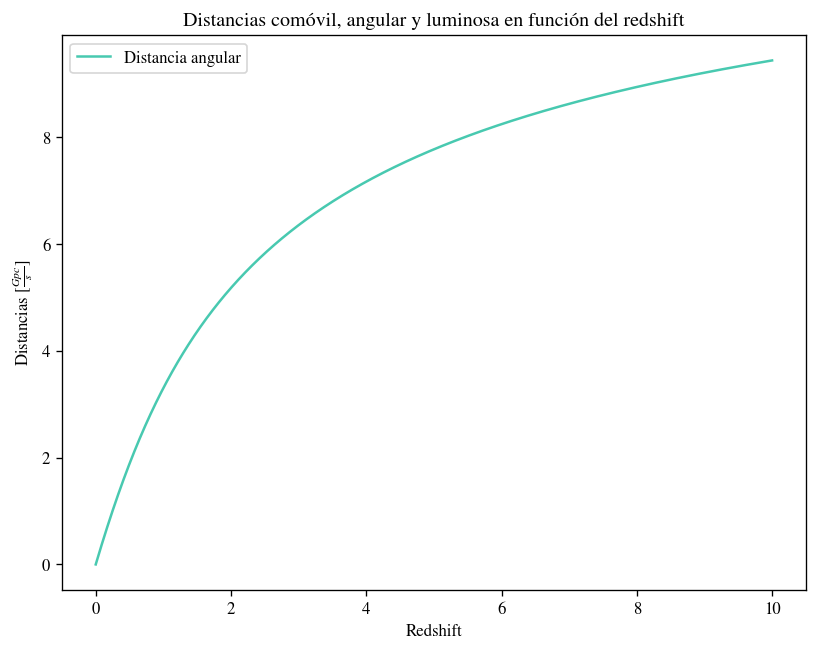

In [5]:
# En esta celda incluiremos la graficación de las distancias, para ello utilizaremos un linspae que será el espacio del redshift
z = np.linspace(0,10,1000)

# Colores
colors = ['#C39BD3', '#F7DC6F', '#EF91CB', '#48C9B0', '#98FB98', '#FA8072']

plt.figure(figsize=(8, 6))


# Graficación de cada distancia
#plt.plot(z,d_comovil(z,H0,omega_m,omega_R,omega_l,n=10000),label = 'Distancia comovil',color=colors[0])
#plt.plot(z,d_lumin(z,H0,omega_m,omega_R,omega_l,n=10000),label = 'Distancia luminosa',color=colors[2])
plt.plot(z,d_angular(z,H0,omega_m,omega_R,omega_l,n=10000),label = 'Distancia angular',color=colors[3])

plt.title('Distancias comóvil, angular y luminosa en función del redshift')
plt.xlabel('Redshift')
plt.ylabel('Distancias '+r'$[\frac{Gpc}{s}]$')
plt.legend()
#plt.grid(True)
plt.show()


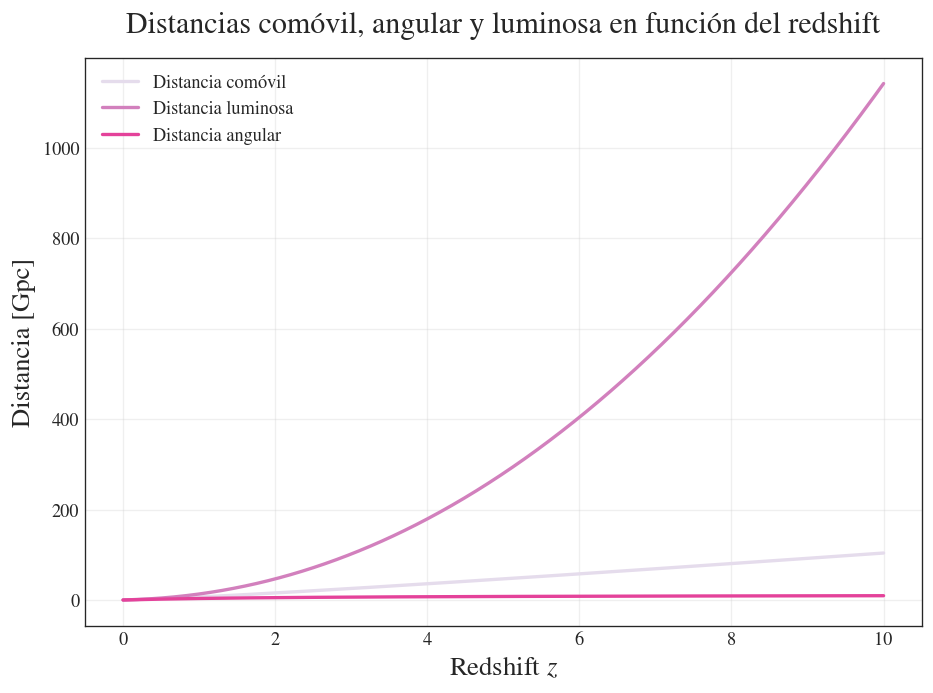

In [6]:
import seaborn as sns

sns.set_style("white")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14
})

colors=sns.color_palette("PuRd")

plt.figure(figsize=(8, 6))

# Graficación de cada distancia
plt.plot(z, d_comovil(z,H0,omega_m,omega_R,omega_l,n=10000), 
         label='Distancia comóvil', color=colors[0], lw=2)
plt.plot(z, d_lumin(z,H0,omega_m,omega_R,omega_l,n=10000), 
         label='Distancia luminosa', color=colors[2], lw=2)
plt.plot(z, d_angular(z,H0,omega_m,omega_R,omega_l,n=10000), 
         label='Distancia angular', color=colors[3], lw=2)

# Título y etiquetas con estilo más académico
plt.title('Distancias comóvil, angular y luminosa en función del redshift', fontsize=18, pad=15)
plt.xlabel('Redshift $z$', fontsize=16)
plt.ylabel(r'Distancia [Gpc]', fontsize=16)

# Límites y ejes
'''plt.xlim(0, 10)
plt.ylim(0, None)'''
plt.tick_params(axis='both', which='major', labelsize=11, direction='in', length=6, width=1)
plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
plt.minorticks_on()

# Cuadro de leyenda más claro
plt.legend(frameon=False, fontsize=11, loc='upper left')

# Fondo y cuadrícula sutil
plt.grid(True, alpha=0.3)

# # Quita bordes superiores y derechos (estilo “journal”)
# for spine in ['top', 'right']:
#     plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


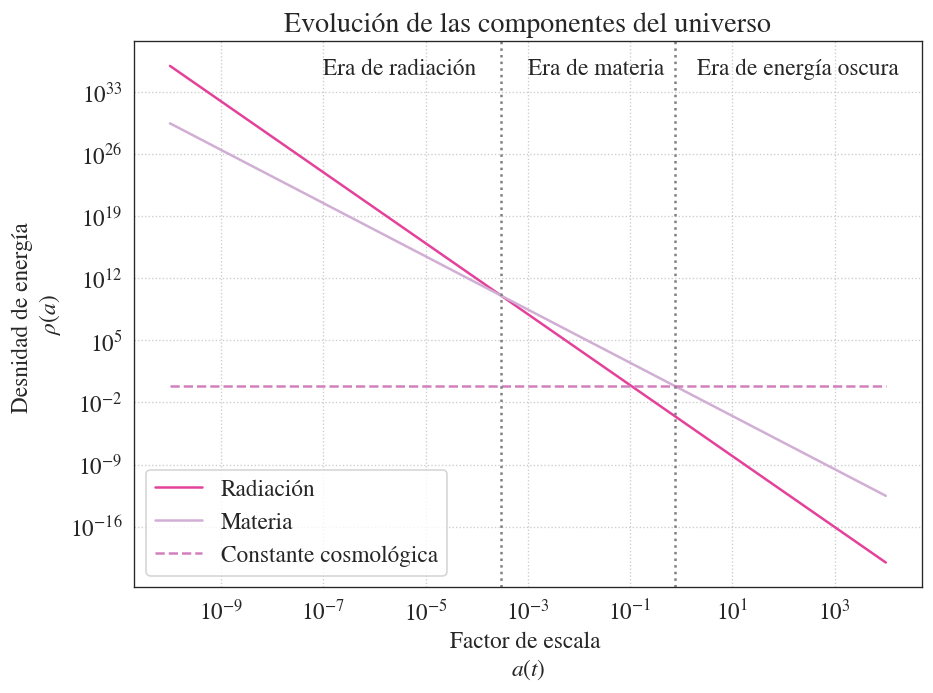

In [7]:
# rango del factor de escala
a = np.logspace(-10, 4, 500)

# densidades normalizadas al valor actual
rho_r = 9e-5*a**(-4)
rho_m = 0.3*a**(-3)
rho_L = 0.7*np.ones_like(a)

idx = np.argmin(np.abs(rho_r - rho_m))

a_eq1 = 9e-5/0.3

idx = np.argmin(np.abs(rho_m - rho_L))

a_eq2 = a[idx]



plt.figure(figsize=(8,6))

plt.loglog(a, rho_r, color=colors[3], label='Radiación')
plt.loglog(a, rho_m, color=colors[1], label='Materia')
plt.loglog(a, rho_L, color=colors[2], linestyle='--', label='Constante cosmológica')
# etiquetas
plt.xlabel('Factor de escala \n'r'$a(t)$', fontsize=14)
plt.ylabel('Desnidad de energía \n'r'$\rho(a)$', fontsize=14)
plt.title('Evolución de las componentes del universo')

# líneas verticales ejemplo
plt.axvline(a_eq1, color='gray', linestyle=':')
plt.axvline(a_eq2, color='gray', linestyle=':')
# plt.axvline(1, color='black', linestyle=':')

plt.text(1e-7, 1e35, 'Era de radiación')
plt.text(1e-3, 1e35, 'Era de materia')
plt.text(2, 1e35, 'Era de energía oscura')

plt.legend()

plt.grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()


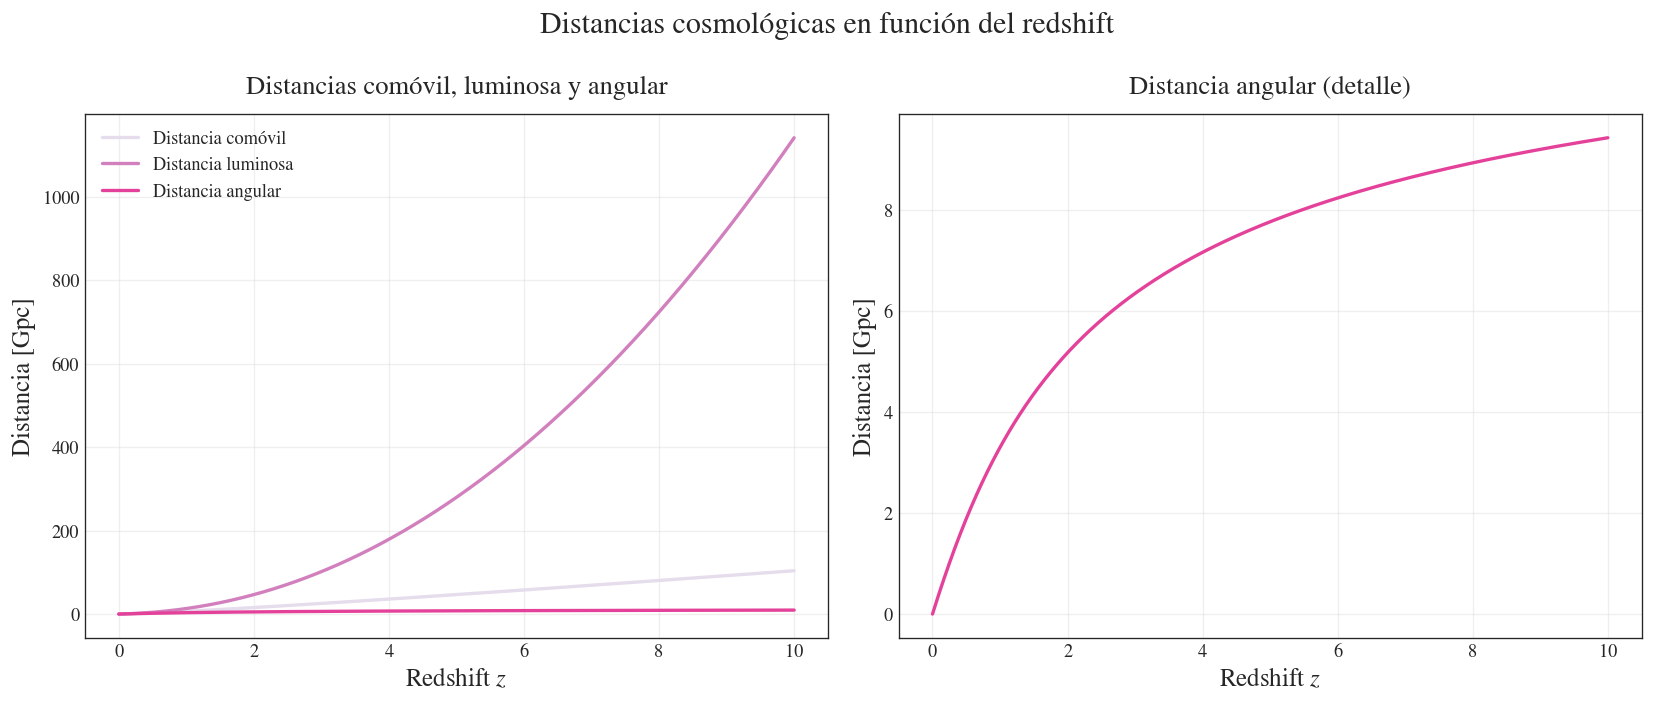

In [10]:
import seaborn as sns

sns.set_style("white")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14
})

colors = sns.color_palette("PuRd")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: las tres distancias juntas ---
ax1.plot(z, d_comovil(z, H0, omega_m, omega_R, omega_l, n=10000),
         label='Distancia comóvil', color=colors[0], lw=2)
ax1.plot(z, d_lumin(z, H0, omega_m, omega_R, omega_l, n=10000),
         label='Distancia luminosa', color=colors[2], lw=2)
ax1.plot(z, d_angular(z, H0, omega_m, omega_R, omega_l, n=10000),
         label='Distancia angular', color=colors[3], lw=2)

ax1.set_title('Distancias comóvil, luminosa y angular', fontsize=16, pad=12)
ax1.set_xlabel('Redshift $z$', fontsize=15)
ax1.set_ylabel('Distancia [Gpc]', fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=11, direction='in', length=6, width=1)
ax1.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
ax1.minorticks_on()
ax1.legend(frameon=False, fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Panel 2: distancia angular sola, para ver su máximo ---
ax2.plot(z, d_angular(z, H0, omega_m, omega_R, omega_l, n=10000),
         color=colors[3], lw=2)

ax2.set_title('Distancia angular (detalle)', fontsize=16, pad=12)
ax2.set_xlabel('Redshift $z$', fontsize=15)
ax2.set_ylabel('Distancia [Gpc]', fontsize=15)
ax2.tick_params(axis='both', which='major', labelsize=11, direction='in', length=6, width=1)
ax2.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
ax2.minorticks_on()
ax2.grid(True, alpha=0.3)

fig.suptitle('Distancias cosmológicas en función del redshift', fontsize=18)
plt.tight_layout()
plt.show()